In [1]:
#======================#
#   Import Libraries   #
#======================#

import ROOT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
from scipy.optimize import curve_fit

RUN = 668

In [2]:
#==================#
#   Data Loading   #
#==================#

# limit number of events to load
nmax = int(1e7)

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/ROOT/run{RUN}.root")
rdf = ROOT.RDataFrame("DataR", f).Range(nmax)  # take up to nmax entries
events = rdf.AsNumpy(columns=["Channel", "Energy"])

Channel = events["Channel"]
Energy = events["Energy"]

BGO1 = Energy[Channel == 1]
BGO2 = Energy[Channel == 2]
BGO3 = Energy[Channel == 3]
BGO4 = Energy[Channel == 4]
BGO5 = Energy[Channel == 5]
BGO6 = Energy[Channel == 6]
BGO = [BGO1, BGO2, BGO3, BGO4, BGO5, BGO6]

print(f"Loaded {len(Channel):.2e} events (max {nmax})")

Loaded 1.00e+07 events (max 10000000)


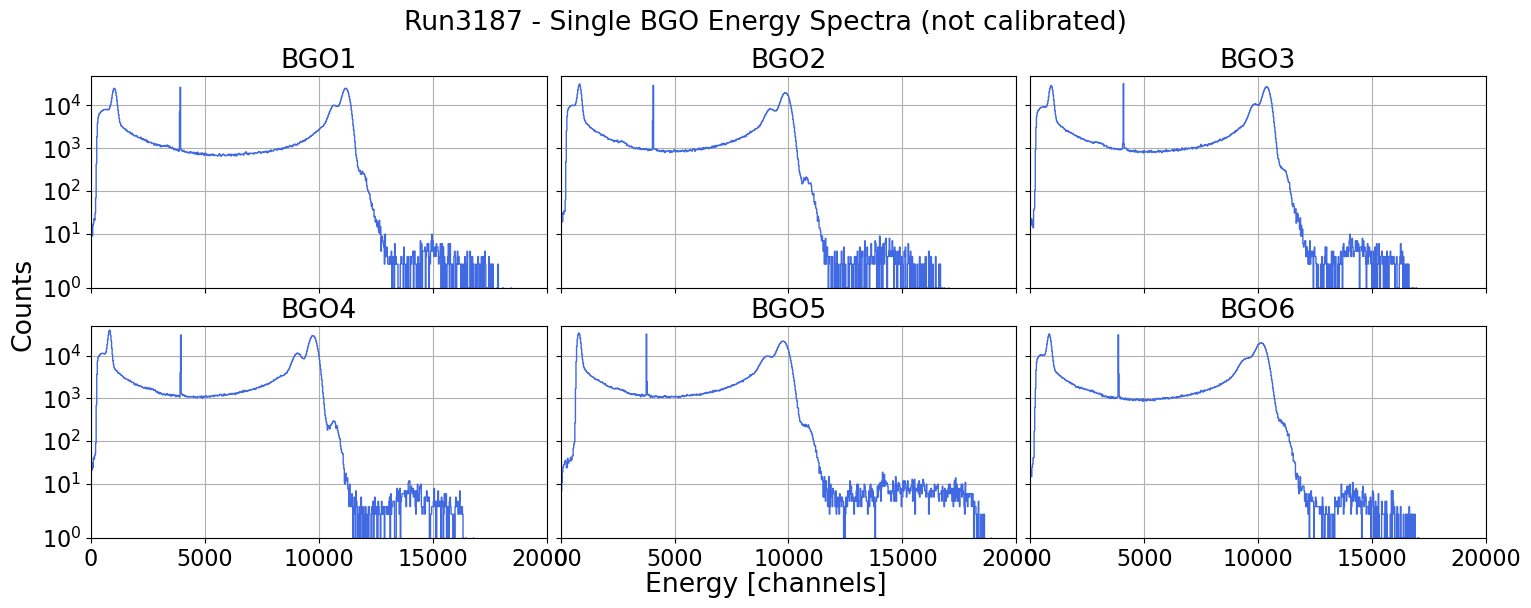

In [3]:
#===================================#
#   Plotting Uncalibrated Spectra   #
#===================================#

fig, [[ax0,ax1,ax2],[ax3,ax4,ax5]] = plt.subplots(2, 3, figsize=(18,6), sharex=True, sharey=True)
axes = [ax0,ax1,ax2,ax3,ax4,ax5]

fig.suptitle(f"Run{RUN} - Single BGO Energy Spectra (not calibrated)", y=0.99)
fig.supxlabel("Energy [channels]", y=0.01)
fig.supylabel("Counts", x=0.08)
plt.yscale("symlog")

for i in range(6):
    axes[i].set_title(f"BGO{i+1}")
    axes[i].hist(BGO[i], bins=np.linspace(1, 20000, 800), histtype='step', label="BGO{}".format(i+1), color="royalblue")
    axes[i].set_xlim(0, 20000)
    axes[i].set_ylim(1, None)
    axes[i].grid()

plt.subplots_adjust(hspace=0.18, wspace=0.03)

plt.show()

3187,BGO1,511.0,1013.33
3187,BGO1,5617.0,10739.16
3187,BGO1,6128.0,11174.55
3187,BGO1,7050.0,11884.80
3187,BGO1,12256.0,14946.40
3187,BGO2,511.0,824.66
3187,BGO2,5617.0,9229.24
3187,BGO2,6128.0,9857.32
3187,BGO2,7050.0,10722.88
3187,BGO2,12256.0,14199.22
3187,BGO3,511.0,911.74
3187,BGO3,5617.0,9886.92
3187,BGO3,6128.0,10366.55
3187,BGO3,7050.0,11043.97
3187,BGO3,12256.0,14245.53
3187,BGO4,511.0,806.48
3187,BGO4,5617.0,9076.55
3187,BGO4,6128.0,9734.91
3187,BGO4,7050.0,10635.38
3187,BGO4,12256.0,14019.70
3187,BGO5,511.0,813.67
3187,BGO5,5617.0,9024.33
3187,BGO5,6128.0,9753.79
3187,BGO5,7050.0,10746.11
3187,BGO5,12256.0,14220.62
3187,BGO6,511.0,834.08
3187,BGO6,5617.0,9449.84
3187,BGO6,6128.0,10139.15
3187,BGO6,7050.0,11001.70
3187,BGO6,12256.0,14106.46


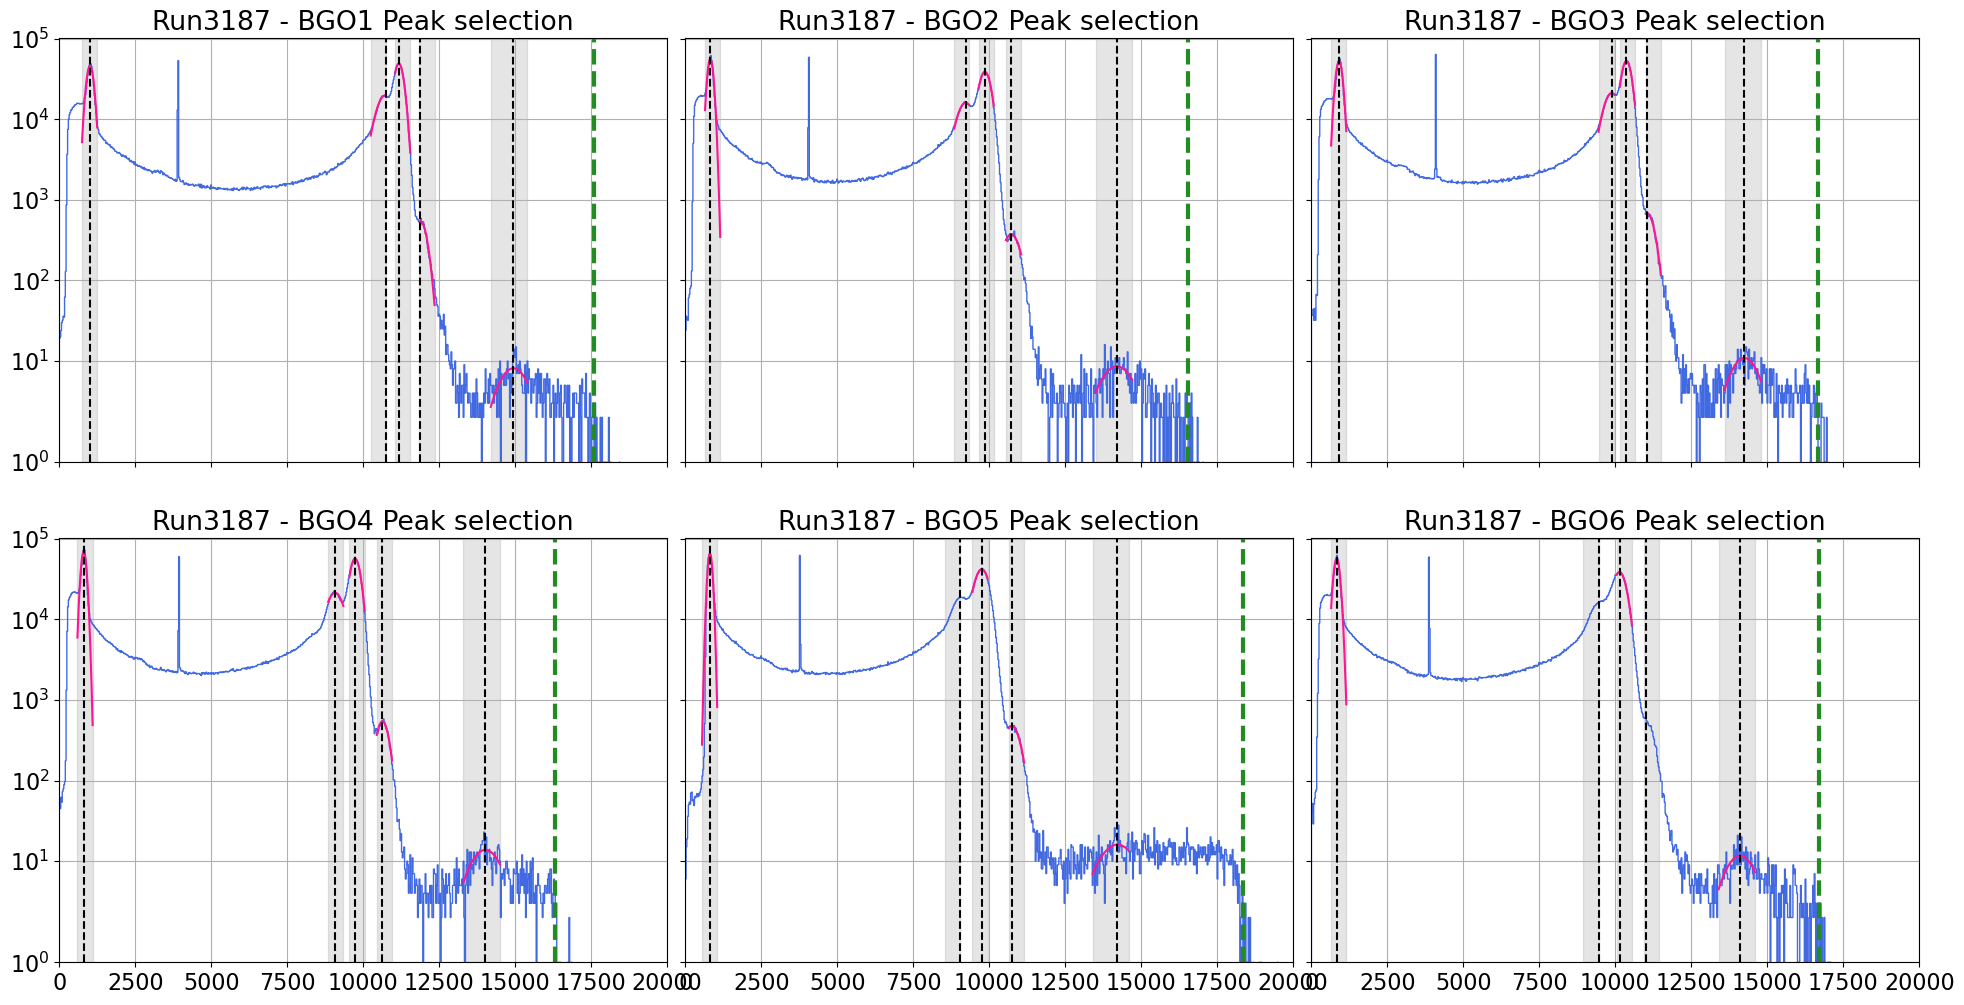

[np.float64(17584.6013767209), np.float64(16533.339799749687), np.float64(16658.489987484354), np.float64(16308.069461827283), np.float64(18335.50250312891), np.float64(16708.550062578222)]


(1784,
 ndarray([839, 351, 739, ..., 1007, 718, 3873], dtype=object),
 1779.0,
 3843.11)

In [13]:
#=====================#
#   Peaks Selection   #
#=====================#

from email.mime import base


BGOs_focus = np.arange(1,7)

# ROI @340 Beamtime 2
# ROI_center = [
#     [400, 4500, 4900, 9200],
#     [400, 4600, 5150, 9600],
#     [400, 4100, 4500, 8800],
#     [400, 4300, 4700, 9000],
#     [400, 4500, 5000, 9600],
#     [400, 4700, 5300, 9500],
# ]

# ROI #240 Beamtime 2
# ROI_center = [
#     [400, 4600, 5100, 9000],
#     [400, 4600, 5150, 9000],
#     [400, 4150, 4700, 8600],
#     [400, 4300, 4700, 8600],
#     [400, 4500, 5000, 9100],
#     [400, 4900, 5300, 9300],
    # [400, 3800, 5150, 9000],
    # [400, 3800, 5150, 9100],
    # [400, 3500, 4700, 8700],
    # [400, 3500, 4700, 8700],
    # [400, 3600, 5000, 9200],
    # [600, 3800, 5300, 9200],
# ]

# a,b,c,d,e,f = 900, 4300, 10250, 11000, 11700, 14600 # Beamtime 3
# a,b,c,d,e,f = 900, 4700, 10500, 11200, 12100, 14300 # Beamtime 4
# a,b,c,d,e = 1000, 8000, 9000, 15000, 17000 # 10B target beamtime 5
a,b,c,d,e,f = 1000, 3450, 10500, 11300, 12100, 14800
# base_values = np.array([a,b,c,d,e,f],float)
# base_values = np.array([a,b,c,d,e],float)
base_values = np.array([a,b,c,d,e,f],float)

# a,b,c,d,e,f,g,h = 1000, 1600, 2800, 5000, 10000, 11300, 12000, 12400,
# base_values = np.array([a,b,c,d,e,f,g,h],float)

# Idx regions to be neglected
neglect = [1]

# # ROI Beamtime 3
# ROI_center = [
#     # BGO1
#     base_values,
#     # BGO2
#     base_values - np.array([100,800,1400,1200,1100,600],float),
#     # BGO3
#     base_values - np.array([100,600,850,700,290,500],float),
#     # BGO4
#     base_values - np.array([150,800,1300,1300,1000,800],float),
#     # BGO5
#     base_values - np.array([200,900,1400,1300,900,700],float),
#     # BGO6
#     base_values - np.array([100,700,900,1000,700,900],float)
# ]

# # ROI Beamtime 4
# ROI_center = [
#     # BGO1
#     base_values,
#     # BGO2
#     base_values - np.array([100,700,1400,1400,1100,600],float),
#     # BGO3
#     base_values - np.array([100,500,700,600,525,500],float),
#     # BGO4
#     base_values - np.array([150,800,1300,1200,1000,800],float),
#     # BGO5
#     base_values - np.array([200,900,1400,1400,1000,800],float),
#     # BGO6
#     base_values - np.array([100,500,800,800,900,1000],float)
# ]

ROI_center = [
    # BGO1
    base_values,
    # BGO2
    base_values - np.array([100,800,1400,1400,1300,700],float),
    # BGO3
    base_values - np.array([100,500,800,900,850,600],float),
    # BGO4
    base_values - np.array([150,800,1400,1500,1400,900],float),
    # BGO5
    base_values - np.array([200,800,1700,1600,1200,800],float),
    # BGO6
    base_values - np.array([100,500,1300,1000,900,800],float)
]

# ROI_center = [
#     # BGO1
#     base_values,
#     # BGO2
#     base_values - np.array([100,200,400,900,1200,1000,900,800],float),
#     # BGO3
#     base_values - np.array([100,200,500,900,1000,800,800,600],float),
#     # BGO4
#     base_values - np.array([150,300,600,900,1600,1400,1200,1000],float),
#     # BGO5
#     base_values - np.array([200,300,600,900,1600,1400,1200,900],float),
#     # BGO6
#     base_values - np.array([100,200,400,700,900,1000,1000,800],float)
# ]

if len(neglect) > 0:
    neg = np.array(neglect, dtype=int)
    new_ROI_center = []
    for roi in ROI_center:
        mask = np.ones(roi.size, dtype=bool)
        valid = neg[neg < roi.size]
        if valid.size > 0:
            mask[valid] = False
        new_ROI_center.append(roi[mask])
    ROI_center = new_ROI_center

ROI_sigma = 250.0

# Energies = np.array([511, 1779, 6128-511, 6128, 7050, 6128*2],float) # keV
# Energies = np.array([511, 1633, 6128-511, 6128, 7050, 10203],float) # Tested with 10203 from 27Al(p,g)28Si from 11986 keV level
# Energies = np.array([511, 3396.0, 4438.9, 11660.1, 16094.4],float) # 10B target beamtime 5
Energies = np.array([511, 1779, 6128-511, 6128, 7050, 6128*2],float) # keV
# Energies = np.array([511, 763, 1380, 2373, 5182, 6175, 6792, 7564],float) # keV

# remove energies at indices in neglect (handles multiple indices)
if len(neglect) > 0:
    Energies = np.delete(Energies, neglect)

def gauss_linearBKG(x, a, x0, sigma, m, q):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + m * np.log(x) + q

def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

fig, axes = plt.subplots(2, 3, figsize=(24, 12), sharex=True, sharey=True)
axs = axes.flatten()

BGO_cuts = []

for i, BGO_focus in enumerate(BGOs_focus):
    ax = axs[i]
    ax.set_title(f"Run{RUN} - BGO{BGO_focus} Peak selection")
    ax.set_yscale("symlog")

    hist = ax.hist(BGO[BGO_focus - 1], bins=np.linspace(1, 20000, 800), histtype='step', lw=3, color="royalblue")
    bin_centers = (hist[1][:-1] + hist[1][1:]) / 2

    counts = hist[0]
    idx_start = np.searchsorted(bin_centers, 15000, side='right')
    cut_val = 20000
    # require a consecutive window of 20 bins whose mean count < 1
    if idx_start <= len(counts) - 20:
        for i in range(idx_start, len(counts) - 19):
            if counts[i:i+20].mean() < 1:
                cut_val = bin_centers[i]
                break
    BGO_cuts.append(cut_val)

    ax.axvline(BGO_cuts[-1], color='forestgreen', ls='--', lw=3)

    for idx, center in enumerate(ROI_center[BGO_focus-1]):
        if Energies[idx] < 10000:
            ROI_sigma = 250
        else:
            ROI_sigma = 600
        mask = (bin_centers >= center - ROI_sigma) & (bin_centers <= center + ROI_sigma)
        xdata = bin_centers[mask]
        ydata = hist[0][mask]

        ax.axvspan(center - ROI_sigma, center + ROI_sigma, color='grey', alpha=0.2)

        try:
            if xdata.size == 0 or ydata.size == 0:
                # Empty ROI: mark center as peak, plot line and print, then skip fitting
                x0 = center
                ax.axvline(x0, color="black", linestyle='--')
                print(f"{RUN},BGO{BGO_focus},{Energies[idx]},{x0:.2f}")
                continue
            p0 = [ydata.max(), center, 60]
            popt, pcov = curve_fit(gauss, xdata, ydata, p0=p0, method='trf')
            amp, x0, sigma = popt
            if amp <= 0 or sigma <= 0 or not (center - ROI_sigma <= x0 <= center + ROI_sigma) or sigma > ROI_sigma * 3:
                raise ValueError("Unreasonable fit result")

            x_fit = np.linspace(center - ROI_sigma, center + ROI_sigma, 1000)
            y_fit = gauss(x_fit, *popt)
            ax.plot(x_fit, y_fit, color="deeppink")
            err = np.sqrt(pcov[1,1]) if pcov is not None else np.nan
            ax.axvline(x0, color="black", ls="--")

        except Exception:
            x0 = xdata[np.argmax(ydata)]
            ax.axvline(x0, color="black", linestyle='--')

        energy = Energies[idx] if idx < Energies.size else None
        if energy is not None:
            print(f"{RUN},BGO{BGO_focus},{energy},{x0:.2f}")

    ax.set_xlim(0, 20000)
    ax.set_ylim(1, None)
    ax.grid()

plt.subplots_adjust(hspace=0.18, wspace=0.03)

plt.show()

print(BGO_cuts)

1784,BGO1,1779.0,4279.21
1784,BGO2,1779.0,3495.61
1784,BGO3,1779.0,3722.58
1784,BGO4,1779.0,3540.97
1784,BGO5,1779.0,3451.74
1784,BGO6,1779.0,3843.11

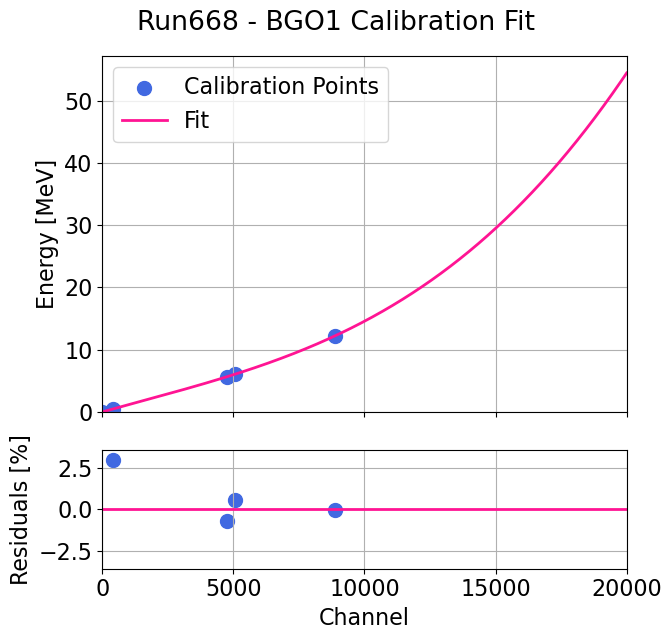

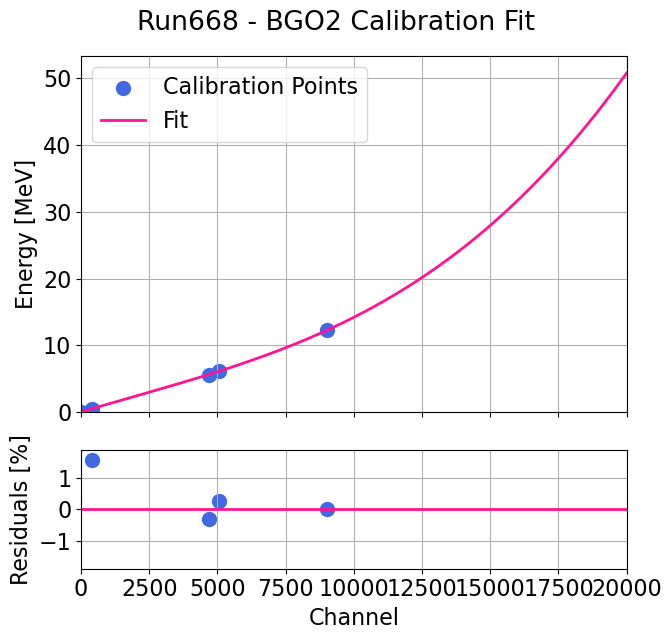

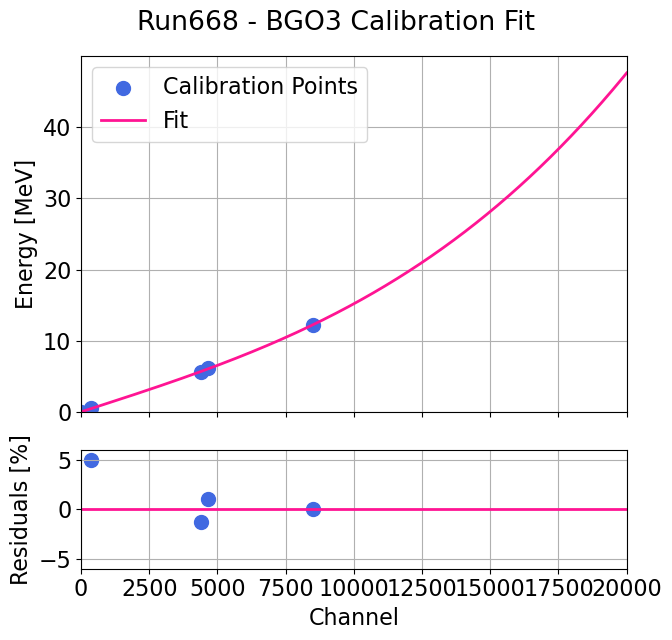

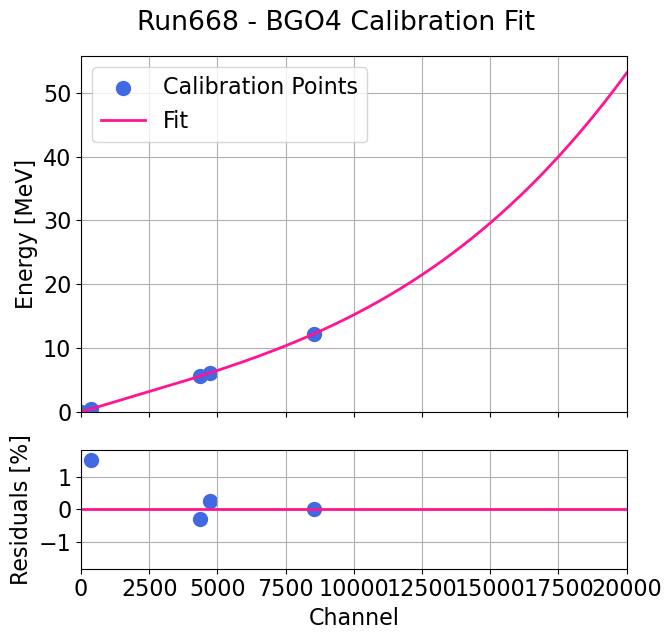

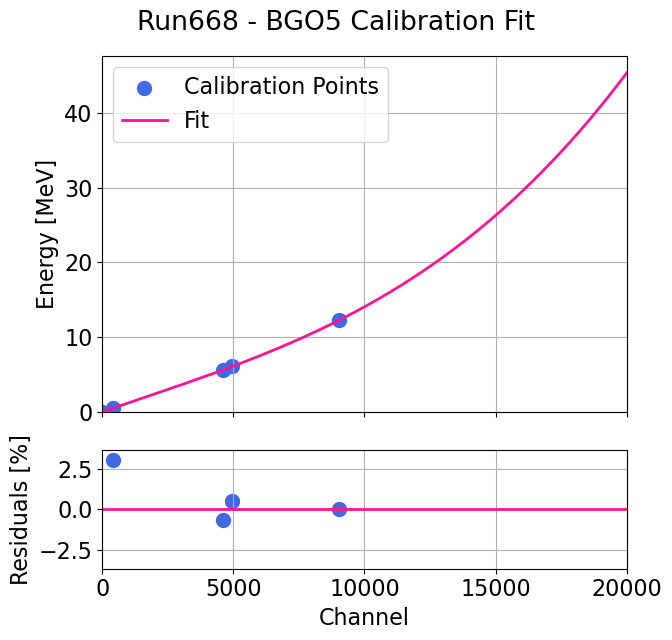

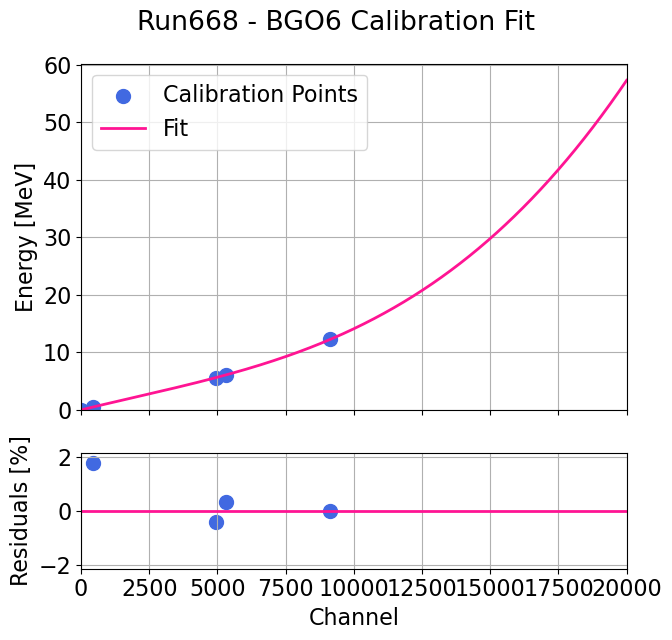

In [2]:
#=====================#
#   Calibration Fit   #
#=====================#

# BGO_cuts = [np.float64(17309.27096370463), np.float64(16333.099499374217), np.float64(17184.12077596996), np.float64(16458.249687108888), np.float64(16633.459949937424), np.float64(16533.339799749687)]


def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def fourth_order(x, a, b, c, d, e,):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

def fifth_order(x, a, b, c, d, e, f):
    return a * x**5 + b * x**4 + c * x**3 + d * x**2 + e * x + f

df = pd.read_csv("/data0/biasissi/LUNA/19F+p_g+20Ne/Calibration/calibration_lines_longruns.csv", delimiter=",")
df = df[df["Run"] == RUN]

params = []

for BGO in range(1,7):
    df_BGO = df[df["BGO"] == f"BGO{BGO}"]

    # original calibration points (Energy in MeV)
    Energy = (df_BGO["Energy"].values / 1e3)
    Channel = df_BGO["Channel"].values

    # add the (0,0) calibration point
    Channel = np.concatenate(([0], Channel))
    Energy = np.concatenate(([0], Energy))

    # # add the (BGO_cut, 14500) calibration point
    # Channel = np.concatenate(([BGO_cuts[BGO-1]], Channel))
    # Energy = np.concatenate(([17.5], Energy))
    

    # fit cubic to the augmented arrays
    popt, pcov = curve_fit(cubic, Channel, Energy)

    # store parameters in keV units (consistent with previous behavior)
    params.append(popt * 1e3)

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7,7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

    fig.suptitle(f"Run{RUN} - BGO{BGO} Calibration Fit", y=0.92)

    # Top: calibration points (including (0,0)) and cubic fit
    ax0.scatter(Channel, Energy, color='royalblue', label='Calibration Points', s=100)
    x_fit = np.linspace(0, 20000, 1000)
    y_fit = cubic(x_fit, *popt)
    ax0.plot(x_fit, y_fit, color='deeppink', label='Fit', lw=2)

    ax0.set_ylabel("Energy [MeV]")
    ax0.set_xlim(0, 20000)
    ax0.set_ylim(0, None)
    ax0.grid()
    ax0.legend()

    # Bottom: relative residuals computed only on original points (exclude the artificial 0,0 to avoid div-by-zero)
    mask = Energy != 0
    if mask.sum() == 0:
        resid = np.zeros_like(Energy)
    else:
        resid = (Energy[mask] - cubic(Channel[mask], *popt)) / Energy[mask] * 100
    ax1.scatter(Channel[mask], resid, color='royalblue', s=100)
    ax1.axhline(0, color='deeppink', lw=2)

    if resid.size:
        ax1.set_ylim(-np.max(np.abs(resid)) * 1.2, np.max(np.abs(resid)) * 1.2)
    else:
        ax1.set_ylim(-1, 1)

    ax1.set_xlabel("Channel")
    ax1.set_ylabel("Residuals [%]")

    ax1.grid()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [4]:
#===================================#
#   Generate the Calibration File   #
#===================================#

out_fname = f"Params/calibration_run{RUN}.txt"
with open(out_fname, "w") as f:
    f.write("0	0	1\n")
    for i, p in enumerate(params, start=1):
        # write params in opposite order (c,b,a) for quadratic a*x^2 + b*x + c
        f.write(f"{i}\t" + "\t".join(map(str, p[::-1])) + "\n")
    f.write("7	0	1")
print(f"Calibration file written: {out_fname}")

Calibration file written: Params/calibration_run668.txt


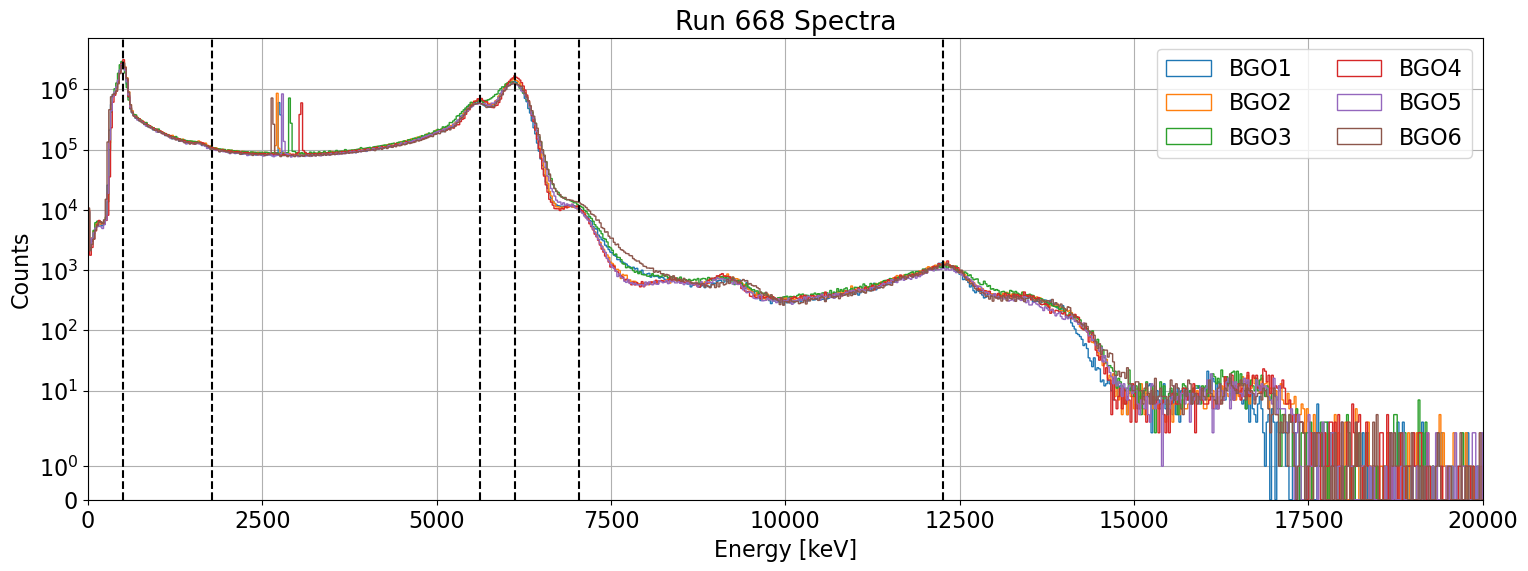

In [3]:
#==================#
#   Data Loading   #
#==================#

# limit number of events to load
nmax = int(1e9)

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/ROOT/run{RUN}.root")
rdf = ROOT.RDataFrame("DataR", f).Range(nmax)  # take up to nmax entries
events = rdf.AsNumpy(columns=["Channel", "Energy"])

Channel = events["Channel"]
Energy = events["Energy"]

BGO1 = Energy[Channel == 1]
BGO2 = Energy[Channel == 2]
BGO3 = Energy[Channel == 3]
BGO4 = Energy[Channel == 4]
BGO5 = Energy[Channel == 5]
BGO6 = Energy[Channel == 6]
BGO = [BGO1, BGO2, BGO3, BGO4, BGO5, BGO6]

# # read rows 1..6 (skip the first header line) and keep only the parameter columns
# popts = np.genfromtxt(f"Params/calibration_run{RUN}.txt", dtype=float, delimiter=None, skip_header=1, max_rows=6)
# # drop the leading index column (first column)
# if popts.ndim == 1:
#     popts = popts[1:]
# else:
#     popts = popts[:, 1:]

# # Reverse each row
# popts = popts[:, ::-1]

#=================================================#
#   Plot Single Crystals & Sum Spectrum Spectra   #
#=================================================#

plt.figure(figsize=(18, 6))

plt.title(f'Run {RUN} Spectra')

plt.yscale('symlog')

# plt.hist(events["energySum"], bins=np.linspace(1, 20000, 1200), histtype='step', color='deeppink', linewidth = 2, label='Sum Spectrum')

for i in range(6):
    plt.hist(cubic(BGO[i], *params[i]), bins=np.linspace(1, 20000, 800), histtype='step', label="BGO{}".format(i+1))
    
    # hist(events[f"energyBGO{i+1}"], bins=np.linspace(1, 20000, 1200), histtype='step', label=f'BGO {i+1}')

# plt.axvline(109.0, color='black', ls='--')
plt.axvline(6128, color='black', ls='--')
plt.axvline(6128-511, color='black', ls='--')
plt.axvline(7050, color='black', ls='--')
plt.axvline(1779, color='black', ls='--')
plt.axvline(511, color='black', ls='--')
# plt.axvline(11660, color='black', ls='--')
plt.axvline(6128*2, color='black', ls='--')
# plt.axvspan(5000,8000, color='gray', alpha=0.3, label=r'${}^{19}F(p,\alpha\gamma){}^{16}O$ ROI')

# plt.axvline(3396.0, color='black', ls='--')
# plt.axvline(4438.9, color='black', ls='--')
# plt.axvline(12256.0, color='black', ls='--')
# plt.axvline(16094.4, color='black', ls='--')

plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

plt.xlim(0, 20000)
plt.ylim(0, None)

plt.grid()
plt.legend(loc='upper right', ncols=2)

plt.show()